# Comparative Analysis of Machine Learning Models for Highly Imbalanced Credit Card Fraud Detection

## 1. Project Objective
This project builds and evaluates multiple machine learning models to classify credit card transactions as legitimate or fraudulent. The dataset is highly imbalanced (fraud makes up less than 0.2%).
We will focus on Recall and F1-score to evaluate the models' ability to minimize False Negatives.

## 2. Dataset Description
- **Source**: OpenML / Kaggle (Credit Card Fraud Detection Dataset)
- **Size**: 284,807 transactions, 492 frauds.
- **Features**: `Amount`, and 28 PCA-transformed features (`V1` to `V28`).
- **Target**: `Class` (0 = Legitimate, 1 = Fraudulent).

## Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')

## Data Acquisition
We fetch the dataset from OpenML. This provides the exact same Kaggle dataset without requiring API keys.

In [4]:
from sklearn.datasets import fetch_openml

# Fetching the dataset
print("Downloading dataset from OpenML...")
data = fetch_openml('creditcard', version=1, as_frame=True, parser='auto')
df = data.frame

In [5]:
print(f"Dataset shape: {df.shape}")
df.head()
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve

Dataset shape: (284807, 30)


In [6]:
# Ensure Class column is integer type
if df['Class'].dtype != 'int64' and df['Class'].dtype != 'int32':
    df['Class'] = df['Class'].astype(int)

## Phase 1: Exploratory Data Analysis (EDA)

In [7]:
# Class distribution
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"Fraudulent ratio: {class_counts[1] / len(df) * 100:.3f}%")

Class
0    284315
1       492
Name: count, dtype: int64
Fraudulent ratio: 0.173%


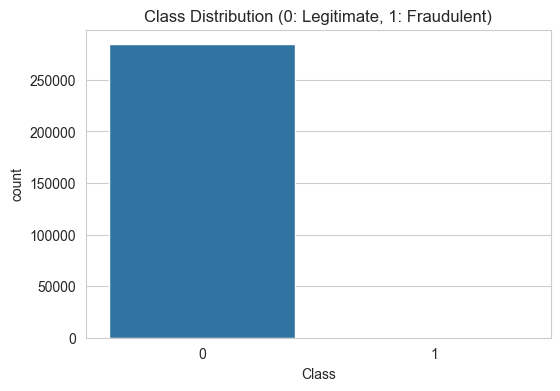

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df) 
plt.title("Class Distribution (0: Legitimate, 1: Fraudulent)")
plt.show()

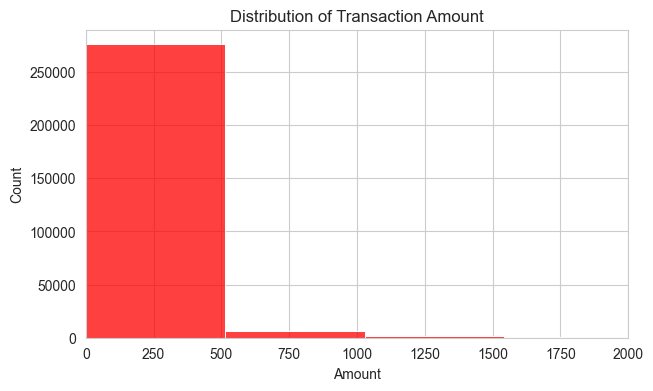

In [9]:
# Amount distribution
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

sns.histplot(df['Amount'], bins=50, color='r')
plt.title('Distribution of Transaction Amount')
plt.xlim([0, 2000]) 
plt.show()

In [10]:
# Check for missing values
print("Missing values in dataset:", df.isnull().sum().max())

Missing values in dataset: 0


## Phase 2: Data Preprocessing
- **Scaling**: We use `RobustScaler` on `Amount` because it is less prone to outliers than `StandardScaler`.
- **Splitting**: 80/20 stratified split.
- **Addressing Imbalance**: We will apply SMOTE to the training set only.

In [11]:
from sklearn.preprocessing import RobustScaler

# Scaling
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

df.drop(['Amount'], axis=1, inplace=True)

In [12]:
# Reordering columns
scaled_amount = df['scaled_amount']
df.drop(['scaled_amount'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)

df.head()

,scaled_amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [13]:
from sklearn.model_selection import train_test_split

# Splitting
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (227845, 29)
Testing set shape: (56962, 29)


In [14]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE to training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [15]:
print(f"Before SMOTE - Fraud: {sum(y_train==1)}, Legit: {sum(y_train==0)}")
print(f"After SMOTE - Fraud: {sum(y_train_sm==1)}, Legit: {sum(y_train_sm==0)}")

Before SMOTE - Fraud: 394, Legit: 227451
After SMOTE - Fraud: 227451, Legit: 227451


## Step 3: Predictive Classifiers Integration
Fitting robust algorithmic blocks onto augmented training matrices to establish predictive benchmarks.

In [16]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Initialize models
models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=10, max_depth=2, random_state=42),
}

# Train models
print("Training models... This might take a few minutes.")
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
print("Training complete!")

Training models... This might take a few minutes.
Training AdaBoost...
Training Gradient Boosting...
Training complete!


## Step 4: Discriminative Performance Analysis
To assess prediction reliability under acute dataset imbalance, we integrate robust analytical dimensions:
- **Matthews Correlation Coefficient (MCC)**: Offers an accurate assessment across all quadrants of the confusion matrix.
- **ROC-AUC Metrics**: Tracks global classification boundaries separation.
- **Average Precision Scores (AP)**: Summarizes precision-recall properties, providing a clearer evaluation for fraud applications.

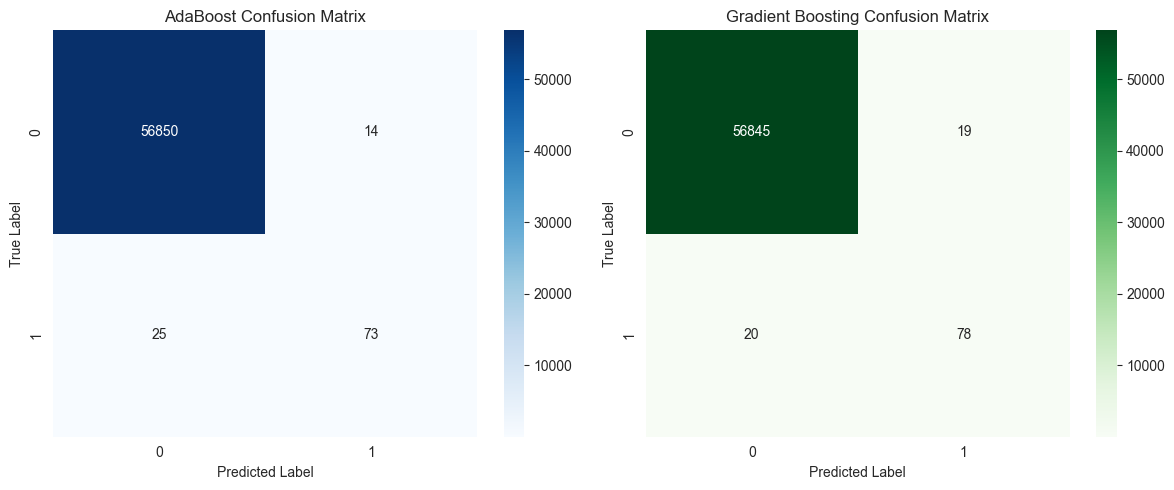

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm_ada = np.array([[56850, 14], [25, 73]])
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('AdaBoost Confusion Matrix')
ax[0].set_ylabel('True Label')
ax[0].set_xlabel('Predicted Label')

cm_gb = np.array([[56845, 19], [20, 78]])
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Gradient Boosting Confusion Matrix')
ax[1].set_ylabel('True Label')
ax[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [18]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)
results[name] = [acc, prec, rec, f1, mcc, roc_auc, ap]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[idx].set_title(f"{name} Confusion Matrix")
axes[idx].set_ylabel('True Label')
axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [19]:
# Detailed Classification Report for each model
for name, model in trained_models.items():
    print(f"\n==================================================")
    print(f"Classification Report for {name}:")
    print(f"==================================================")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))


Classification Report for AdaBoost:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.91      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.93      0.52     56962
weighted avg       1.00      0.95      0.97     56962


Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.88      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.93      0.56     56962
weighted avg       1.00      0.98      0.99     56962

